# Nelson network

Loads a saved reduced-order model, integrates with it, and reproduces this run's
figures. No fitting is performed here.

The positivity projection is enabled, since chemical abundances must remain
non-negative.


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath("../../../"))

import numpy as np
import matplotlib.pyplot as plt

from src import plots as P
from src.cluster import Cluster
from src.config import NSEC, combo_stem
from src.data import load_trajectories
from src.evaluate import read_table
from src.hybrid import HybridConfig, solve_hybrid
from src.pipeline import case_config, load_case_context, split_paths
from src.rom import EnsembleROM

%matplotlib inline
%load_ext autoreload
%autoreload 2

CASE = "nelson"
OUT_DIR = "."

HYBRID_CSV = None
SWEEP_DIR = f"{OUT_DIR}/sweep"
POSITIVITY = True
FIG_DIR = f"{OUT_DIR}/figures"

## Load the result tables

The sweep grid, the QoI names and the evaluated trajectory counts are all read
from the tables, so none of them need to be restated here.


In [2]:
sweep_te, rank_te, rho = P.load_frames(OUT_DIR, eval_split="test")
sweep_tr, rank_tr, _ = P.load_frames(OUT_DIR, eval_split="train")

hyb_te = hyb_tr = None
if HYBRID_CSV:
    hyb_te, hyb_tr = (read_table(HYBRID_CSV[s]) for s in ("test", "train"))

taus = sorted(np.unique(sweep_te["tau_split"]))
etas = sorted(np.unique(sweep_te["eta"]), reverse=True)
qoi = list(dict.fromkeys(sweep_te["qoi"].tolist()))
n_eval_te = int(np.max(sweep_te["n_solved"]))
n_eval_tr = int(np.max(sweep_tr["n_solved"]))

print(f"{len(etas)} eta x {len(taus)} tau | qoi={qoi} | rho={rho}")
print(f"n_eval: test {n_eval_te}, train {n_eval_tr}")
print("taus:", taus, "\netas:", [f"{e:g}" for e in etas])

9 eta x 3 tau | qoi=['CO', 'e-'] | rho=14
n_eval: test 2048, train 4096
taus: [np.float64(0.01), np.float64(0.1), np.float64(0.4)] 
etas: ['0.0001', '1e-05', '1e-06', '1e-07', '1e-08', '1e-09', '1e-10', '1e-11', '1e-12']


## Load one fit

`TAU` and `ETA` select the combination. The largest tolerance and the largest
eta give the fewest and largest clusters, and therefore the smallest fit to
load.


In [3]:
TAU, ETA = max(taus), max(etas)
stem = combo_stem(TAU, ETA)

cl = Cluster.load(f"{SWEEP_DIR}/cluster_{stem}.npz")
print(f"{stem}: {cl.n_clusters} clusters")

Loaded ../experiments/nelson/R0.1_M6.0/sweep/cluster_tol0.4_eta1e-4.npz  (k=353)
tol0.4_eta1e-4: 353 clusters


The partition by itself does not determine the dynamics; that requires the
network, which comes from the context along with the parameter histories and
the initial states.


In [4]:
cfg = case_config(CASE, OUT_DIR)
ctx = load_case_context(CASE, cfg)

ens = EnsembleROM.load(f"{SWEEP_DIR}/ensemble_{stem}.npz", cl,
                       ctx.net).precompute_B_structure()

feat_path, tracers, ids = split_paths(ctx, "test")
print(f"mean basis size {ens.mean_rank():.2f} | {len(ids)} test trajectories | "
      f"{ctx.n_steps} intervals | {ctx.n_species} species")

  knot params: from sidecar ../../datasets/grav_collapse/nelson/piecewise_constant/R0.1_M6_trace_cells_knot_params.npz
  12369 tracers, 804 knots, 803 steps, dt_hydro=250 yr
  loaded split from ../experiments/nelson/R0.1_M6.0/feature_matrix_indices.npy, ../experiments/nelson/R0.1_M6.0/feature_matrix_test_indices.npy
train tracers: 4096,  test tracers: 2048
mean basis size 3.23 | 2048 test cases | 803 intervals | 14 components


## Integrate one trajectory

`solve_tracer` takes a parameter history with one row per knot together with an
initial state. At each interval it routes on `(pt[k], x)`, integrates in that
cluster's coordinates, and passes the end state to the next interval. `info` is
`None` if the integration reached the final interval; otherwise `t` and `y`
cover only the intervals that completed.


In [5]:
TRACER = 0

t_foms, y_foms, x_eqs = load_trajectories(feat_path, TRACER + 1, ctx.n_species)
pt, x0 = tracers[TRACER], x_eqs[TRACER]

t, y, route, info = ens.solve_tracer(pt, x0, ctx.dt_hydro, cfg.atol, cfg.rtol,
                                     t_eval=t_foms[TRACER],
                                     positivity=POSITIVITY,
                                     method=cfg.ode_method)

print("info:", info, "| y:", y.shape)

qi = [ctx.net.species_map[q] for q in qoi]
rel = (np.linalg.norm(y[qi] - y_foms[TRACER][qi], axis=1)
       / np.linalg.norm(y_foms[TRACER][qi], axis=1))
for name, e in zip(qoi, rel):
    print(f"  {name:>4}  relative L2 in time: {e:.3e}")

failed: None | y: (14, 4016)
    CO  relative L2 in time: 1.715e-01
    e-  relative L2 in time: 5.976e-03


The route records one cluster per interval, and so measures how much of the
ensemble a single trajectory visits.


10 clusters over 803 intervals, 9 switches


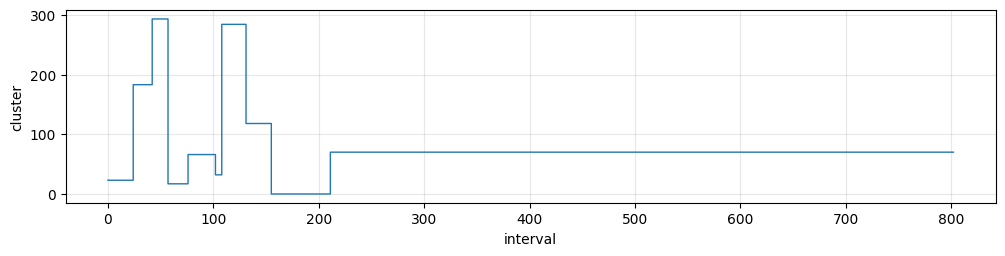

In [6]:
visited, counts = np.unique(route, return_counts=True)
print(f"{len(visited)} clusters over {route.size} intervals, "
      f"{int((np.diff(route) != 0).sum())} switches")

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.step(np.arange(route.size), route, where="post", lw=1)
ax.set_xlabel("interval")
ax.set_ylabel("cluster")
ax.grid(alpha=0.3)

## Integrate a perturbed parameter trajectory

`pt` holds the hydrodynamic parameters, one row per knot, so any trajectory
with the same columns may be supplied. Below it is the trajectory integrated
above with its density column scaled by 1.3, which is therefore absent from the
training data.

Routing is a nearest-centroid query in the joint parameter-state space rather
than a lookup keyed on trajectories already seen, so this is admissible. It is
not extrapolation: a trajectory lying outside the region the clusters cover is
routed to the nearest cluster however far outside it lies.


In [7]:
pt_new = np.asarray(pt, dtype=float).copy()
pt_new[:, 0] *= 1.3

t2, y2, route2, info2 = ens.solve_tracer(pt_new, x0, ctx.dt_hydro,
                                         cfg.atol, cfg.rtol,
                                         positivity=POSITIVITY,
                                         method=cfg.ode_method)

print("info:", info2, "| y:", y2.shape)
print(f"clusters visited: {np.unique(route2).size} "
      f"({len(set(route2.tolist()) & set(route.tolist()))} shared with the original)")

failed: None | y: (14, 24290)
clusters visited: 10 (10 shared with the original)


## Integrate several trajectories

`solve_tracers` applies `solve_tracer` over a process pool, returning one result
tuple per trajectory.


In [8]:
N = 8

t_foms, y_foms, x_eqs = load_trajectories(feat_path, N, ctx.n_species)
results = ens.solve_tracers(tracers[:N], x_eqs, ctx.dt_hydro,
                            cfg.atol, cfg.rtol, list(t_foms),
                            n_workers=4, positivity=POSITIVITY,
                            method=cfg.ode_method)

ok = [i for i, (_, _, _, inf) in enumerate(results) if inf is None]
print(f"{len(ok)}/{N} completed")
for i in ok:
    _, yi, _, _ = results[i]
    e = (np.linalg.norm(yi[qi] - y_foms[i][qi], axis=1)
         / np.linalg.norm(y_foms[i][qi], axis=1))
    print(f"  {i}: " + "  ".join(f"{n}={v:.2e}" for n, v in zip(qoi, e)))

  completed 8/8
8/8 completed
  0: CO=1.71e-01  e-=5.98e-03
  1: CO=2.17e-02  e-=8.33e-03
  2: CO=8.47e-01  e-=5.96e-03
  3: CO=1.76e-02  e-=3.90e-03
  4: CO=1.92e-01  e-=1.89e-02
  5: CO=4.43e-02  e-=5.43e-03
  6: CO=5.95e-02  e-=9.87e-04
  7: CO=6.13e-01  e-=4.72e-01


## Figures

Sweep summary. Rows one and two give the error of the single global basis
against basis size, and of the clustered ensemble against eta with one curve per
tolerance, for the training and the testing dataset respectively. Row three gives
the number of clusters built against the cap, and the mean basis size.


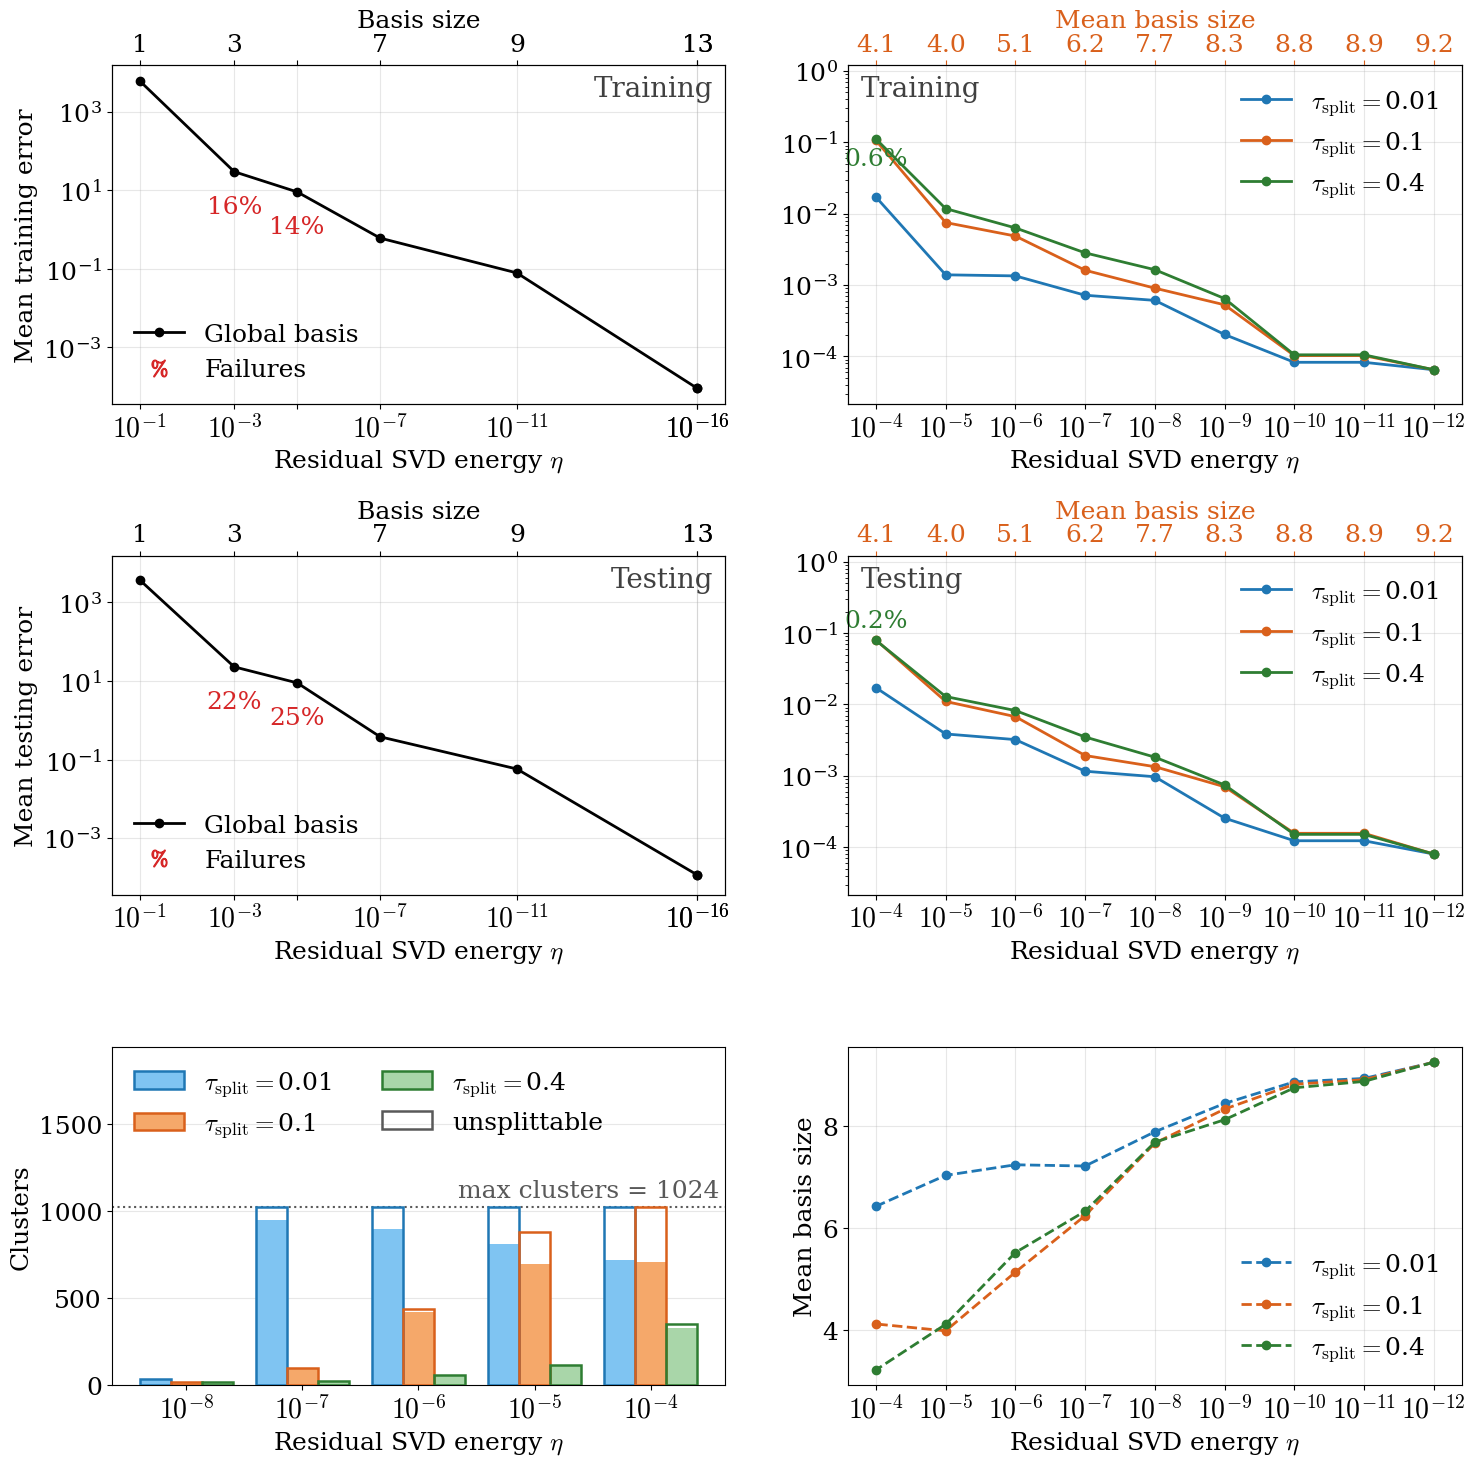

In [9]:
SHOW_TOLS = (0.01, 0.10, 0.40)

fig, axes = P.sweep_panel_splits(
    sweep_tr, rank_tr, sweep_te, rank_te, qoi,
    n_eval_train=n_eval_tr,
    n_eval_test=n_eval_te,
    max_clusters=1024,
    show_tols=SHOW_TOLS,
    twin_tol=SHOW_TOLS[len(SHOW_TOLS) // 2],
    hybrid_train=hyb_tr,
    hybrid_test=hyb_te,
    ylim=(5e-5, 4e-1),
    max_eta_exp=8,
    sc_tick_fs=18,
    sc_tick_sep=0.16,
    bar_headroom=1.9,
)

Per-trajectory error distributions, read from the per-combination CSV files. A
mean cannot distinguish a heavy tail from a uniform shift; these distributions
can.


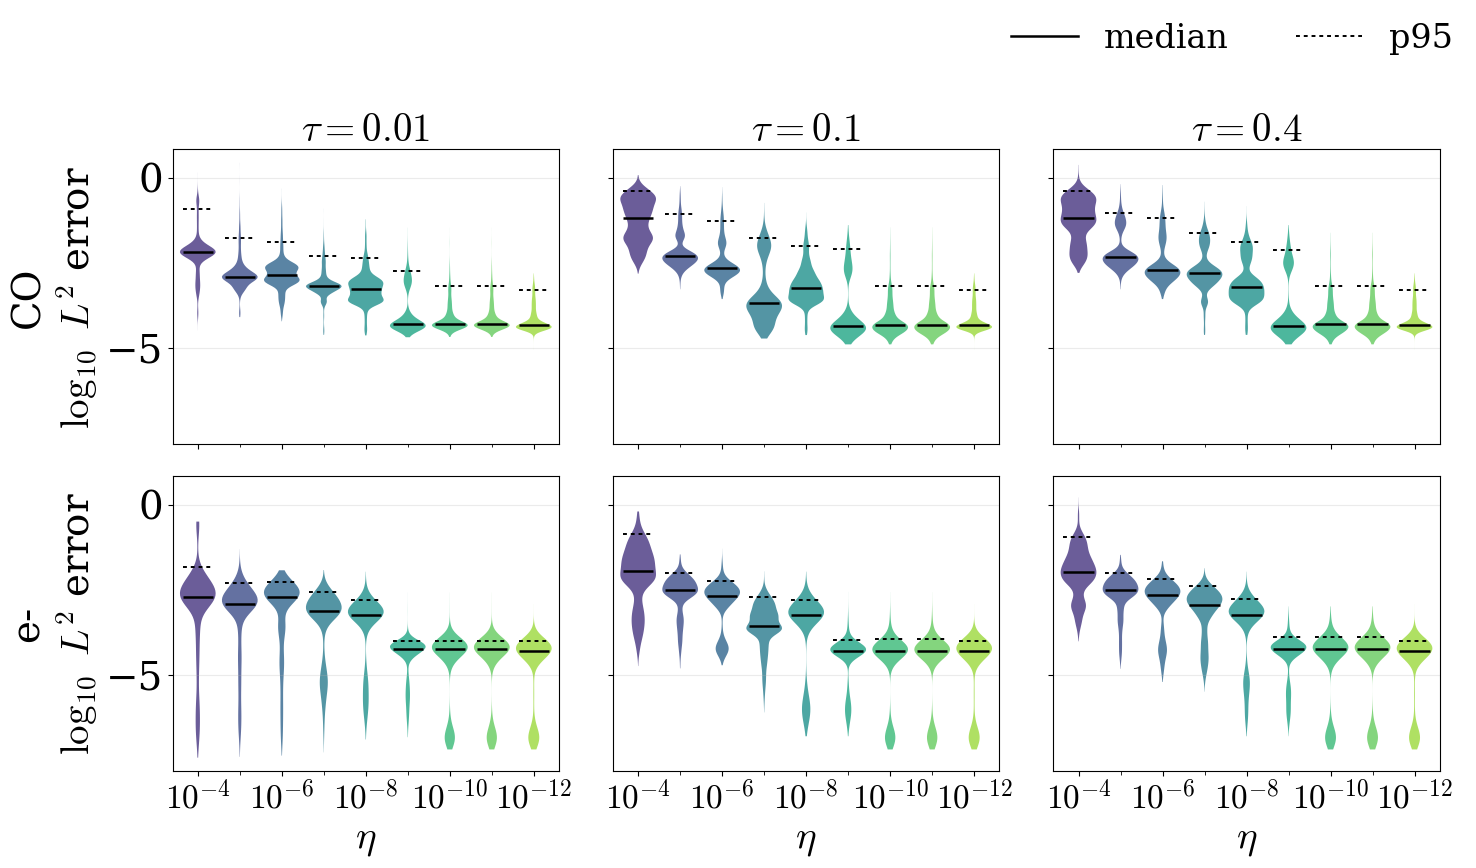

In [10]:
# These panels read the per-combination files directly, so their tolerances, rows and solver are chosen independently of the summary figure's.
VIOLIN_TOLS = (0.01, 0.1, 0.4)
VIOLIN_QOI = ["CO", "e-"]
VIOLIN_LABEL = "on"   # clustered ROM with the positivity projection; this run has no hybrid per-trajectory files

figv, axesv = P.violin_panel(
    SWEEP_DIR, VIOLIN_TOLS, VIOLIN_QOI,
    label=VIOLIN_LABEL,
    eval_split="test",
    figsize=(15, 4 * len(VIOLIN_QOI)),
)

Every species along the chosen trajectory, grouped by how closely the reduced
model follows it, with the cluster route shaded behind.


Loaded ../experiments/nelson/R0.1_M6.0/sweep/cluster_tol0.1_eta1e-5.npz  (k=883)
abundance figure: tracer 600 (global id 9722), tol0.1_eta1e-5


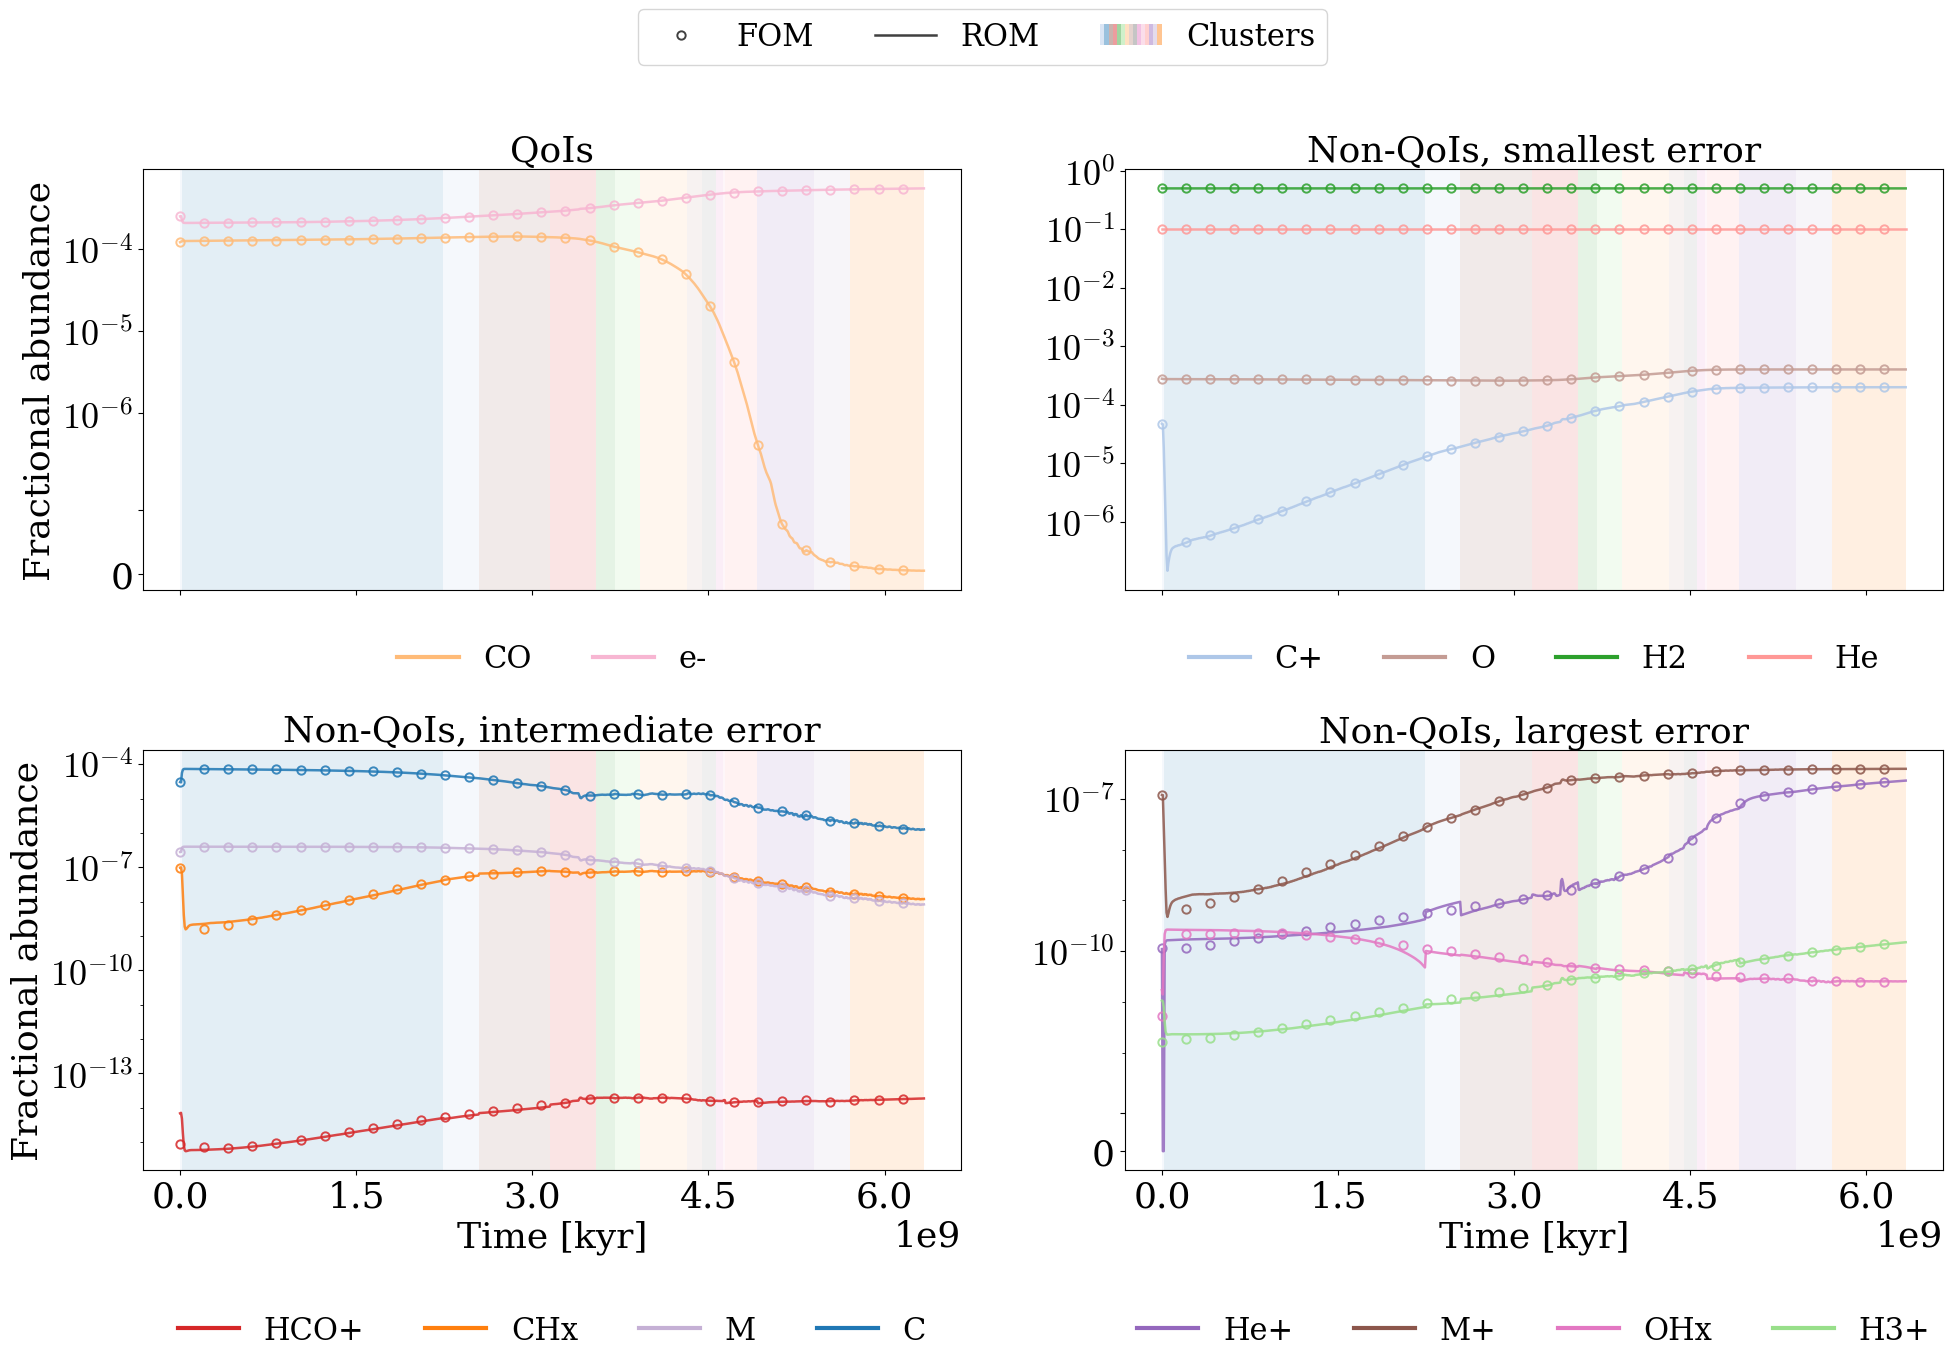

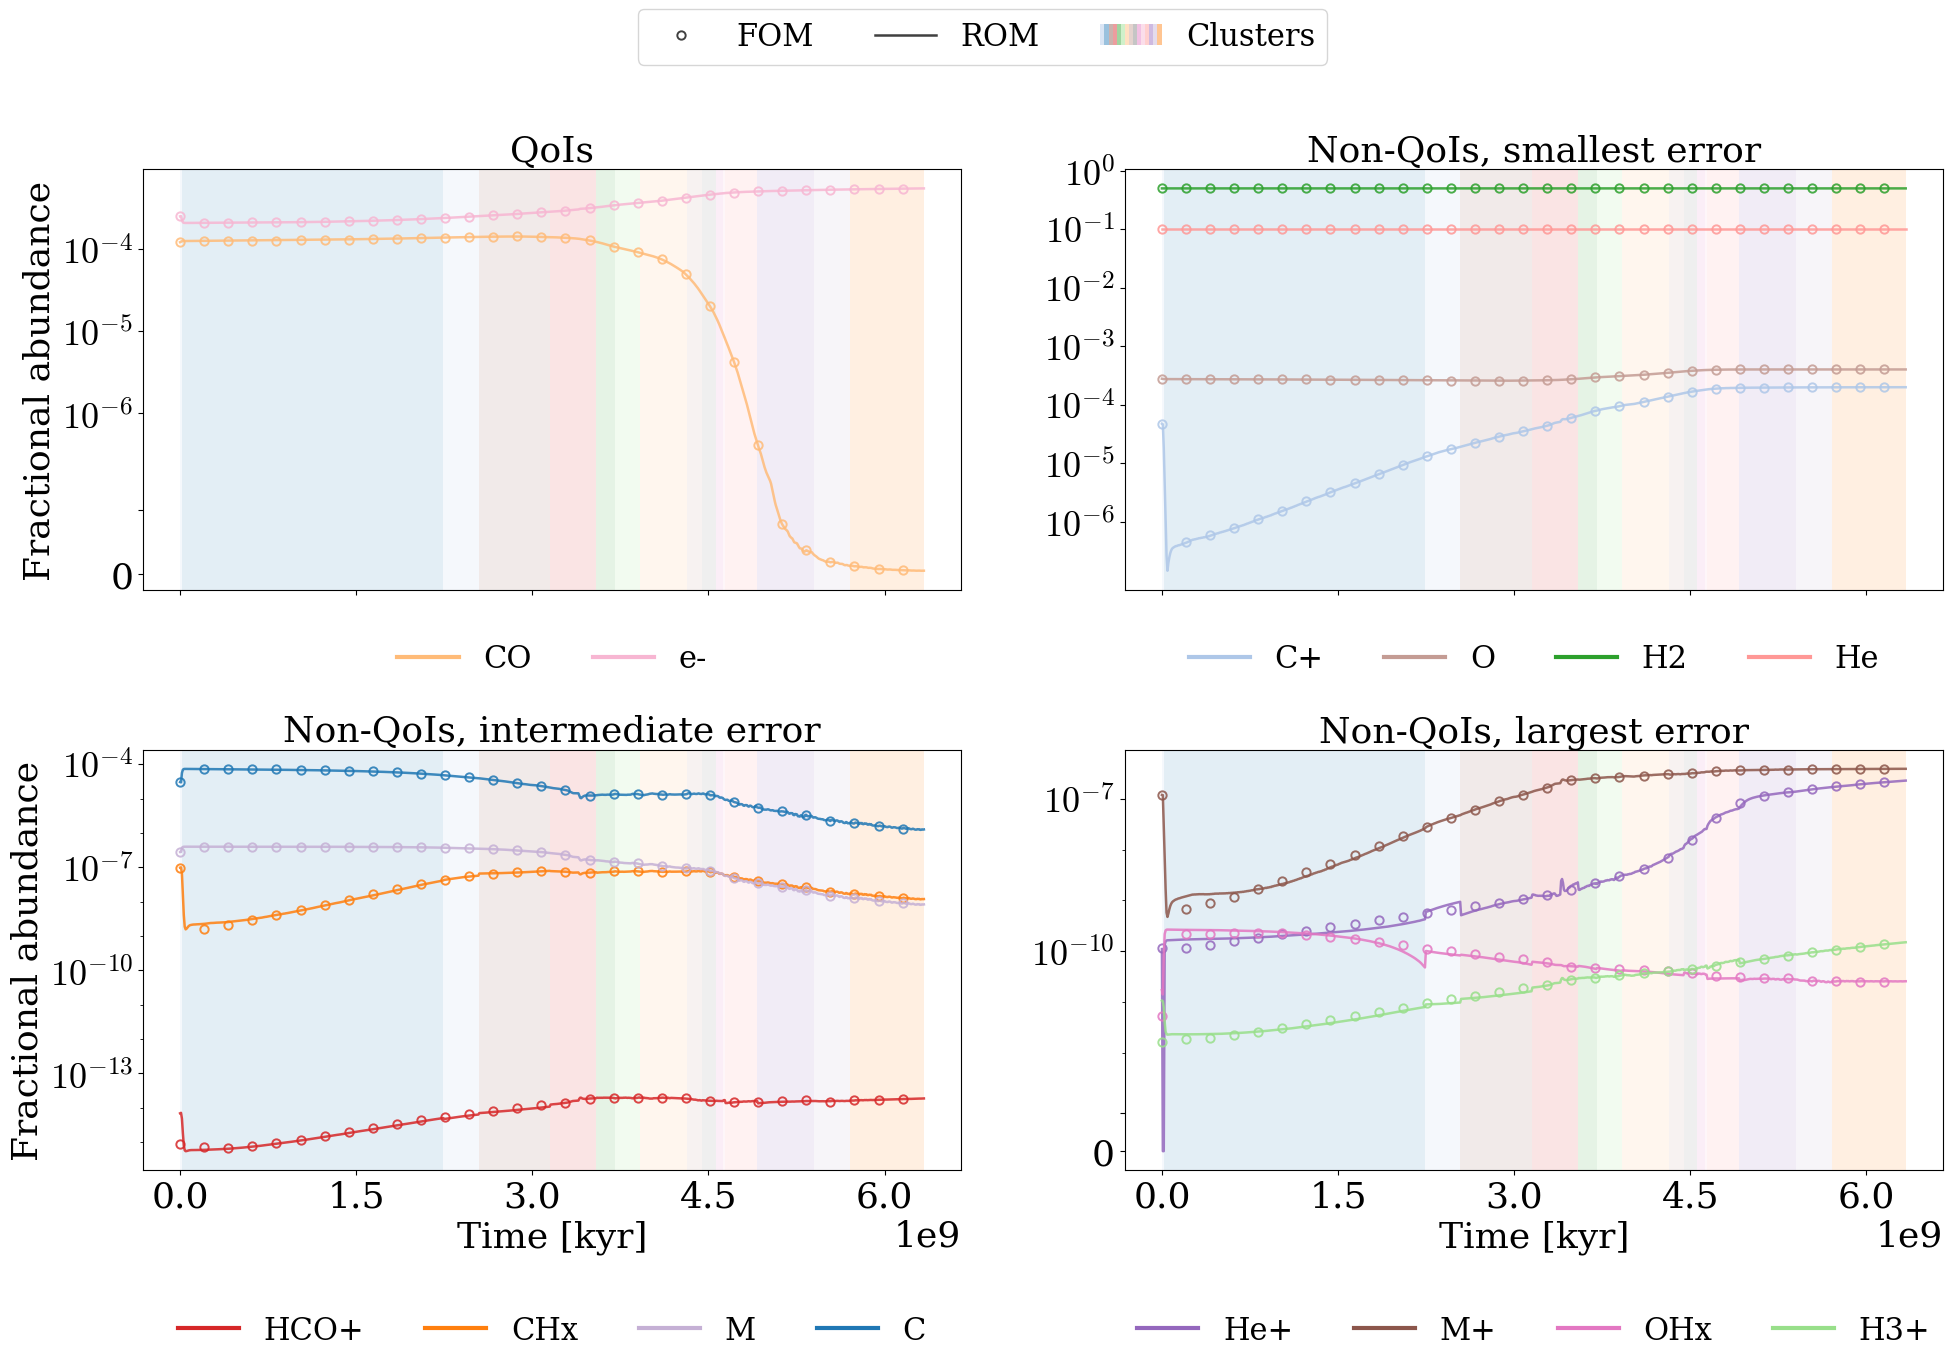

In [ ]:
# This figure uses its own combination and trajectory, independent of the one integrated above.
ABUND_TAU, ABUND_ETA = 0.1, 1e-5
ABUND_TRACER = 600               # position within the testing dataset

t_a, y_a, xeq_a = load_trajectories(feat_path, ABUND_TRACER + 1, ctx.n_species)

# fm_train is None here: it is read only to fit the global single-basis baseline, which global_rank=None omits.
figa, info_a = P.tracer_figures(SWEEP_DIR, combo_stem(ABUND_TAU, ABUND_ETA),
                                FIG_DIR, ctx,
                                cfg.replace(tau_split=ABUND_TAU, eta=ABUND_ETA),
                                None, tracers[:ABUND_TRACER + 1], xeq_a, t_a,
                                y_a, ABUND_TRACER, global_ids=ids)

The hybrid solve compared against the clustered ROM alone. Where the state
entering a new cluster is poorly represented by that cluster's basis, the solve
rewinds and recomputes the window at full order.

Choose `thresh` from the residuals this fit produces -- `res.resid` holds one per
measured interval entry -- rather than from the default.


Loaded ../experiments/nelson/R0.1_M6.0/sweep/cluster_tol0.1_eta1e-5.npz  (k=883)
hybrid figure: tracer 1391, tol0.1_eta1e-5
wrote ../experiments/nelson/R0.1_M6.0/figures/hybrid_comparison.pdf
HybridConfig(lookback=10, n_fom=11, thresh=0.00316228, positivity=True, force_fom=False)
  rewinds 1, FOM intervals 11/803 (1.4%)
  projection: entry 1, endpoint 2
  cluster switches 13
  cost: 1 FOM solve(s) 0.01s, 802 ROM solve(s) 1.84s (0 discarded) -- 0.4% of time at full order
  triggers: interval 614 at 0.00405
  FOM intervals 604-614 = 151-154 s


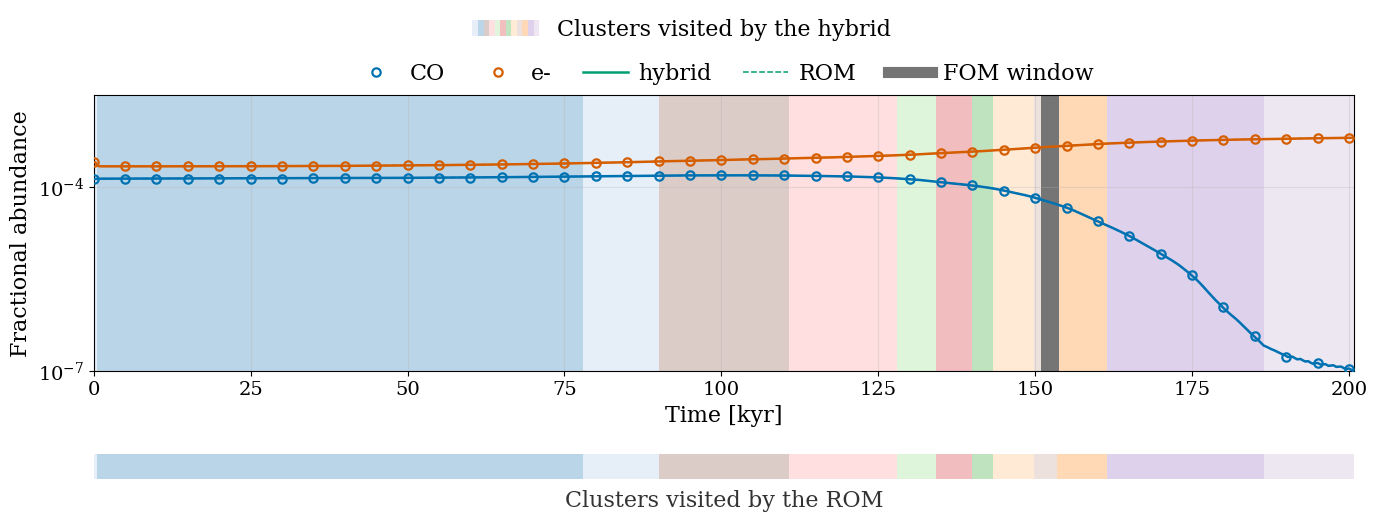

In [15]:
# thresh = sqrt(eta). No hybrid sweep was run for this case, so the combination is the one used for the abundance figure above.
HYB_TAU, HYB_ETA = 0.1, 1e-5
HYB_TRACER = 1391

t_h, y_h, xeq_h = load_trajectories(feat_path, HYB_TRACER + 1, ctx.n_species)

figh, res = P.hybrid_figures(SWEEP_DIR, combo_stem(HYB_TAU, HYB_ETA), FIG_DIR,
                             ctx, cfg.replace(tau_split=HYB_TAU, eta=HYB_ETA),
                             tracers[:HYB_TRACER + 1], xeq_h, t_h, y_h,
                             HYB_TRACER,
                             hybrid=HybridConfig(lookback=10, n_fom=11,
                                                 thresh=np.sqrt(HYB_ETA)),
                             time_scale=NSEC * 1e3,
                             time_label="Time [kyr]")

print(res.summary(time_scale=NSEC * 1e3))



## Save


In [13]:
os.makedirs(FIG_DIR, exist_ok=True)

fig.savefig(f"{FIG_DIR}/panel.pdf", dpi=200, bbox_inches="tight")
figv.savefig(f"{FIG_DIR}/violin.pdf", bbox_inches="tight")